<p style="padding: 20px; background-color: #2ecc71; color: white; border-radius: 10px; text-align: center; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; font-size: 22px; font-weight: bold;">
Human Capital Insights: Segmentación Sociodemográfica y Estrategias de Fidelización del Talento
<br>
<span style="font-size: 16px; font-weight: normal;">
Equipo de Análisis de Perfil y Desempeño
</span>
</p>

In [37]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

RRHH_full = pd.read_csv('full_RRHH.csv')

<p style="padding: 15px; background-color: #2c3e50; color: white; border-radius: 8px; font-family: sans-serif; text-align: center;"> Fase 1: Inteligencia de Negocio y Perfilado Manual</p>


In [2]:
RRHH_full.columns

Index(['ID', 'Reason_absence', 'Month_absence', 'Day_week', 'Seasons',
       'Transportation_expense', 'Distance_Residence_Work', 'Service_time',
       'Age', 'Work_load_Average_day', 'Hit_target', 'Disciplinary_failure',
       'Education', 'Son', 'Social_drinker', 'Social_smoker', 'Pet',
       'Body_mass_index', 'Absenteeism_hours', 'Reason_Description'],
      dtype='object')

C:\Users\josemessiasferreira\AppData\Local\Temp\ipykernel_9496\443261222.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


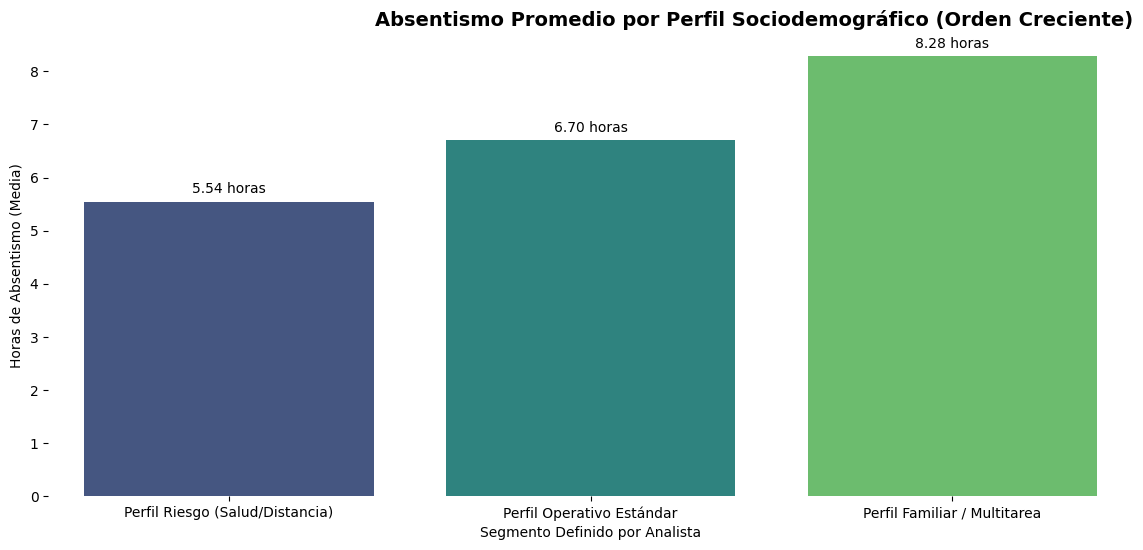

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

def segmentacion_profesional(row):
    if row['Son'] >= 2 or row['Pet'] >= 2:
        return 'Perfil Familiar / Multitarea'
    elif row['Body_mass_index'] > 28 or row['Distance_Residence_Work'] > 35:
        return 'Perfil Riesgo (Salud/Distancia)'
    else:
        return 'Perfil Operativo Estándar'


RRHH_full['Perfil_Analista'] = RRHH_full.apply(segmentacion_profesional, axis=1)


order = RRHH_full.groupby('Perfil_Analista')['Absenteeism_hours'].mean().sort_values().index


plt.figure(figsize=(14, 6))

sns.barplot(
    data=RRHH_full, 
    x='Perfil_Analista', 
    y='Absenteeism_hours', 
    palette='viridis', 
    order=order,
    errorbar=None,
    legend=False     
)


plt.title('Absentismo Promedio por Perfil Sociodemográfico (Orden Creciente)', fontsize=14, loc='right', weight='bold')
plt.ylabel('Horas de Absentismo (Media)')
sns.despine(left=True, bottom=True)
plt.xlabel('Segmento Definido por Analista')

# Opcional: Añadir etiquetas de valor sobre las barras para mayor claridad
ax = plt.gca()
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f} horas', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points')

plt.show()

###  Riesgo (Salud / Distancia)  
**Perfil:** Fatiga logística (>35 km) o salud (BMI > 28).  
**ADN Sociodemográfico:** Exposición a desgaste físico o desplazamientos prolongados.  
**Necesidad Estratégica:** Bienestar – Reducir desgaste físico y reforzar apoyo en salud.<br>
Body_mass_index: Índice de Masa Corporal (valor $> 28$).<br>
Distance_Residence_Work: Distancia al trabajo en km (valor $> 35$).

###  Operativo Estándar  
**Perfil:** Perfiles estables con baja carga de responsabilidades.  
**ADN Sociodemográfico:** Situación personal equilibrada y menor presión externa.  
**Necesidad Estratégica:** Desarrollo – Foco en planes de carrera y formación.<br>
Variable de control: Se define por exclusión.

###  Familiar / Multitarea  
**Perfil:** Alta carga de cuidado (≥2 hijos o mascotas).  
**ADN Sociodemográfico:** Responsabilidades familiares elevadas y gestión simultánea de múltiples tareas.  
**Necesidad Estratégica:** Conciliación – Flexibilidad para gestionar imprevistos domésticos.<br>
Son: Número de hijos (valor $\geq 2$).<br>
Pet: Número de mascotas (valor $\geq 2$).








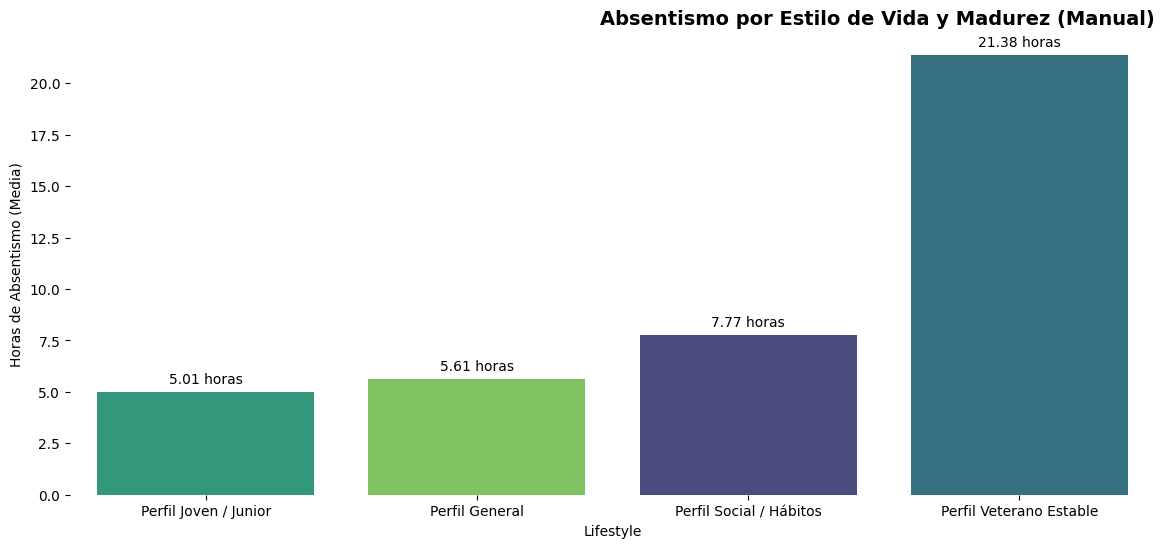

In [15]:

def segmentacion_estilo_vida(row):
    # Perfil A: Estilo de vida social (Hábitos)
    if row['Social_drinker'] == 1 or row['Social_smoker'] == 1:
        return 'Perfil Social / Hábitos'
    
    # Perfil B: Veteranos (Lealtad y Madurez)
    elif row['Service_time'] >= 15 and row['Age'] >= 45:
        return 'Perfil Veterano Estable'
    
    # Perfil C: Jóvenes (Nuevos talentos)
    elif row['Age'] < 30:
        return 'Perfil Joven / Junior'
    
    else:
        return 'Perfil General'

# Aplicamos la nueva lógica
RRHH_full['Lifestyle'] = RRHH_full.apply(segmentacion_estilo_vida, axis=1)

# Ordenamos por absentismo
order_estilo = RRHH_full.groupby('Lifestyle')['Absenteeism_hours'].mean().sort_values().index

# Gráfico
plt.figure(figsize=(14, 6))
ax = sns.barplot(
    data=RRHH_full, 
    x='Lifestyle', 
    y='Absenteeism_hours', 
    hue='Perfil_Estilo_Vida', # Añadido para evitar el FutureWarning
    palette='viridis', 
    order=order_estilo,
    legend=False,
    errorbar=None
)

plt.title('Absentismo por Estilo de Vida y Madurez (Manual)', fontsize=14, loc='right', weight='bold')
plt.ylabel('Horas de Absentismo (Media)')
sns.despine(left=True, bottom=True)

# Etiquetas
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f} horas', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', xytext=(0, 9), textcoords='offset points')

plt.show()

### Perfil Social / Hábitos
**Perfil:** Consumo social activo (bebida o tabaco).
**ADN Sociodemográfico:** Hábitos de interacción social con posible impacto en salud o recuperación física.
**Necesidad Estratégica:** Salud Preventiva – Programas de bienestar y concienciación de hábitos.<br>
Social_drinker: Consumo de alcohol (valor $= 1$).<br>
Social_smoker: Consumo de tabaco (valor $= 1$).


###  Perfil Joven / Junior
**Perfil:** Nuevos talentos en inicio de carrera (menores de 30 años).
**ADN Sociodemográfico:** Generaciones jóvenes en proceso de adaptación cultural.
**Necesidad Estratégica:** Retención – Feedback constante y formación acelerada.<br>
Age: Edad del empleado (valor $< 30$).


###  Perfil Veterano estable
**Perfil:** Alta lealtad y madurez ($\geq 15$ años de servicio y $\geq 45$ años de edad).
**ADN Sociodemográfico:** Empleados con amplio conocimiento institucional y estabilidad vital.
**Necesidad Estratégica:** Reconocimiento – Mentoría y transmisión de conocimiento.<br>
Reconocimiento – Mentoría y transmisión de conocimiento.

###  Perfil General
**Perfil:** Núcleo central sin extremos de edad o hábitos destacados.
**ADN Sociodemográfico:** Situación personal equilibrada con necesidades de gestión estándar.
**Necesidad Estratégica:** Estabilidad – Mantener el compromiso mediante incentivos generales.<br>
Variable de control: Se define por exclusión.


In [ ]:
# 0. Limpieza: Forzamos que las columnas sean numéricas (los errores se convierten en NaN)
RRHH_full['Education'] = pd.to_numeric(RRHH_full['Education'], errors='coerce')
RRHH_full['Transportation_expense'] = pd.to_numeric(RRHH_full['Transportation_expense'], errors='coerce')

# Rellenamos posibles valores vacíos con 0 para que no falle la comparación lógica
RRHH_full[['Education', 'Transportation_expense']] = RRHH_full[['Education', 'Transportation_expense']].fillna(0)

def segmentacion_educacion_logistica(row):
    if row['Education'] > 1:
        return 'Especialista Cualificado'
    elif row['Transportation_expense'] > 260:
        return 'Esfuerzo Económico'
    else:
        return 'Perfil Base / Estable'

RRHH_full['Perfil_Logistica'] = RRHH_full.apply(segmentacion_educacion_logistica, axis=1)

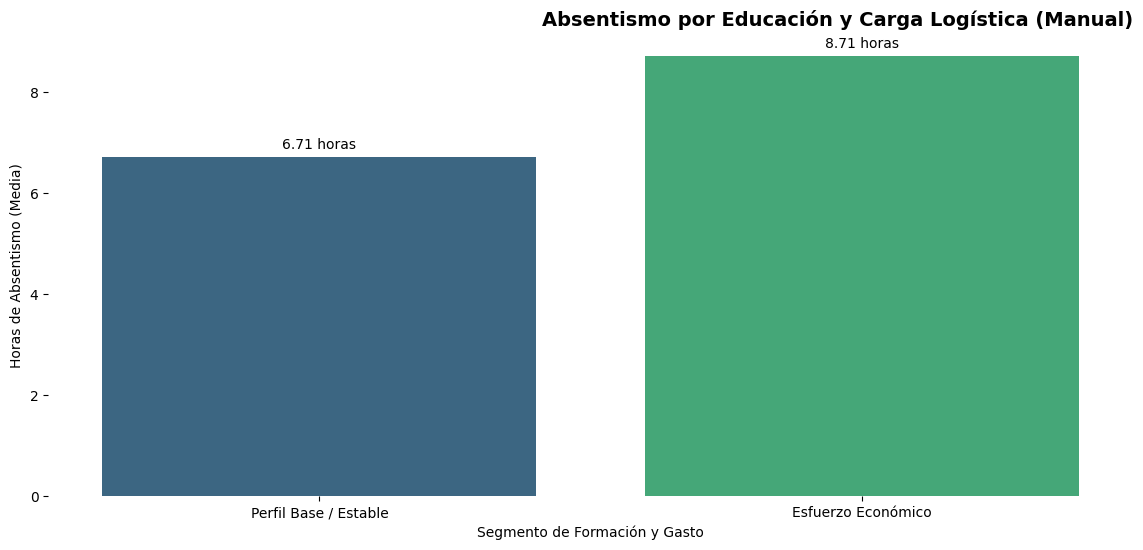

In [21]:

def segmentacion_educacion_logistica(row):
    # Perfil A: Especialista (Nivel de educación superior a secundaria/bachillerato)
    if row['Education'] > 1:
        return 'Especialista Cualificado'
    
    elif row['Transportation_expense'] > 280:
        return 'Esfuerzo Económico'
    
    else:
        return 'Perfil Base / Estable'

RRHH_full['Perfil_Logistica'] = RRHH_full.apply(segmentacion_educacion_logistica, axis=1)


order_logistica = RRHH_full.groupby('Perfil_Logistica')['Absenteeism_hours'].mean().sort_values().index


plt.figure(figsize=(14, 6))
ax = sns.barplot(
    data=RRHH_full, 
    x='Perfil_Logistica', 
    y='Absenteeism_hours', 
    hue='Perfil_Logistica', 
    palette='viridis', 
    order=order_logistica,
    legend=False,
    errorbar=None
)


plt.title('Absentismo por Educación y Carga Logística (Manual)', fontsize=14, loc='right', weight='bold')
plt.ylabel('Horas de Absentismo (Media)')
plt.xlabel('Segmento de Formación y Gasto')
sns.despine(left=True, bottom=True)


for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f} horas', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', xytext=(0, 9), textcoords='offset points')

plt.show()

### Esfuerzo Económico
**Perfil:** Empleados con un gasto de transporte crítico ($> 280R$).
**ADN Sociodemográfico:** Este grupo representa a los trabajadores que sufren un mayor impacto financiero para asistir a su puesto. Es el perfil con mayor riesgo de absentismo debido a la fatiga económica.<br>
Variable: Transportation_expense > 280.


###  Perfil Base / Estable
**Perfil:** Empleados con educación básica y gastos de transporte controlados ($\leq 280$).
**ADN Sociodemográfico:** Representan el grueso de la fuerza operativa (552 empleados). Al no tener el estrés financiero del transporte caro, su absentismo suele ser el estándar de la empresa.<br>
Variable: Definida por exclusión (Gasto bajo + Educación básica).


### Especialista Cualificado (Sin registros)
**Estado:** Estado: Inactivo en esta muestra.<br>
**Razón:** La plantilla analizada es homogénea en su nivel educativo. Esto significa que para este análisis de absentismo, la educación no es un factor diferenciador, pero el gasto de transporte sí lo es.



In [27]:
print(RRHH_full['Perfil_Logistica'].value_counts())

Perfil_Logistica
Perfil Base / Estable    552
Esfuerzo Económico       154
Name: count, dtype: int64



<p style="padding: 15px; background-color: #2c3e50; color: white; border-radius: 8px; font-family: sans-serif; text-align: center;"> Fase 2: Segmentación Inteligente mediante Machine Learning (Clustering K-Means)</p>


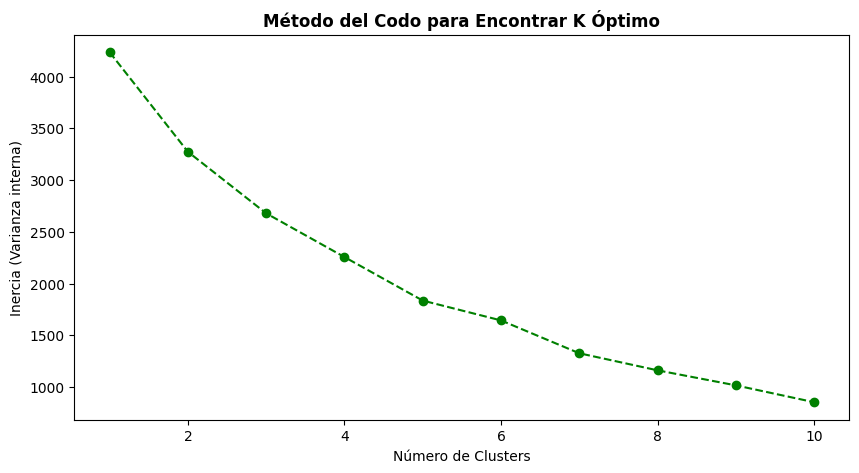

In [38]:
vars_demo = ['Age', 'Body_mass_index', 'Son', 'Pet', 
             'Distance_Residence_Work', 'Transportation_expense']

X = RRHH_full[vars_demo]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

inercia = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inercia.append(kmeans.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), inercia, marker='o', linestyle='--', color='green')
plt.title('Método del Codo para Encontrar K Óptimo', weight='bold')
plt.xlabel('Número de Clusters')
plt.ylabel('Inercia (Varianza interna)')
plt.show()

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

RRHH_full['Cluster_IA'] = kmeans.fit_predict(X_scaled)

perfil_medio = RRHH_full.groupby('Cluster_IA')[vars_demo].mean()

perfil_medio['Absentismo_Promedio'] = RRHH_full.groupby('Cluster_IA')['Absenteeism_hours'].mean()

perfil_medio

c:\Users\josemessiasferreira\miniconda3\envs\sql_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


,Age,Body_mass_index,Son,Pet,Distance_Residence_Work,Transportation_expense,Absentismo_Promedio
Cluster_IA,,,,,,,
0,32.827715,25.157303,1.816479,1.659176,35.176030,274.258427,7.367041
1,42.524064,32.010695,0.593583,0.368984,36.780749,187.449198,5.192513
2,35.861111,24.214286,0.607143,0.123016,17.515873,195.007937,8.353175


<p style="padding: 15px; background-color: #2c3e50; color: white; border-radius: 8px; font-family: sans-serif; text-align: center;"> Resultados de la IA: Los 3 Perfiles de Empleado</p>

**Cluster 0**: El Perfil Familiar y Pendular (Riesgo Alto)
ADN: Es el grupo con más hijos (1.8) y más mascotas (1.6). Además, tienen el mayor gasto en transporte (274).

Absentismo: Alto (7.36 horas).

Conclusión: Este empleado está bajo mucha presión: tiene muchas responsabilidades en casa y un trayecto al trabajo caro y largo.
_________________________

**Cluster 1**: El Perfil Senior Consolidado (Bajo Absentismo)
ADN: Es el grupo de mayor edad (42 años) y mayor IMC (32). Tienen muy pocos hijos y mascotas.

Absentismo: El más bajo de todos (5.19 horas).

Conclusión: A pesar de tener indicadores físicos más altos (BMI), su compromiso o estabilidad vital los hace los más fiables en términos de asistencia.
_________________________
**Cluster 2**: El Perfil Joven de Proximidad (El "Outlier")
ADN: Edad intermedia (35 años), muy buena salud física (BMI bajo de 24) y viven muy cerca del trabajo (Distancia de solo 17.5).

Absentismo: ¡El más alto! (8.35 horas).

Conclusión: ¡Aquí está tu sorpresa! Aunque viven cerca y están sanos, son los que más faltan. Esto sugiere que su absentismo no es por logística o salud, sino quizás por motivación o causas sociales.

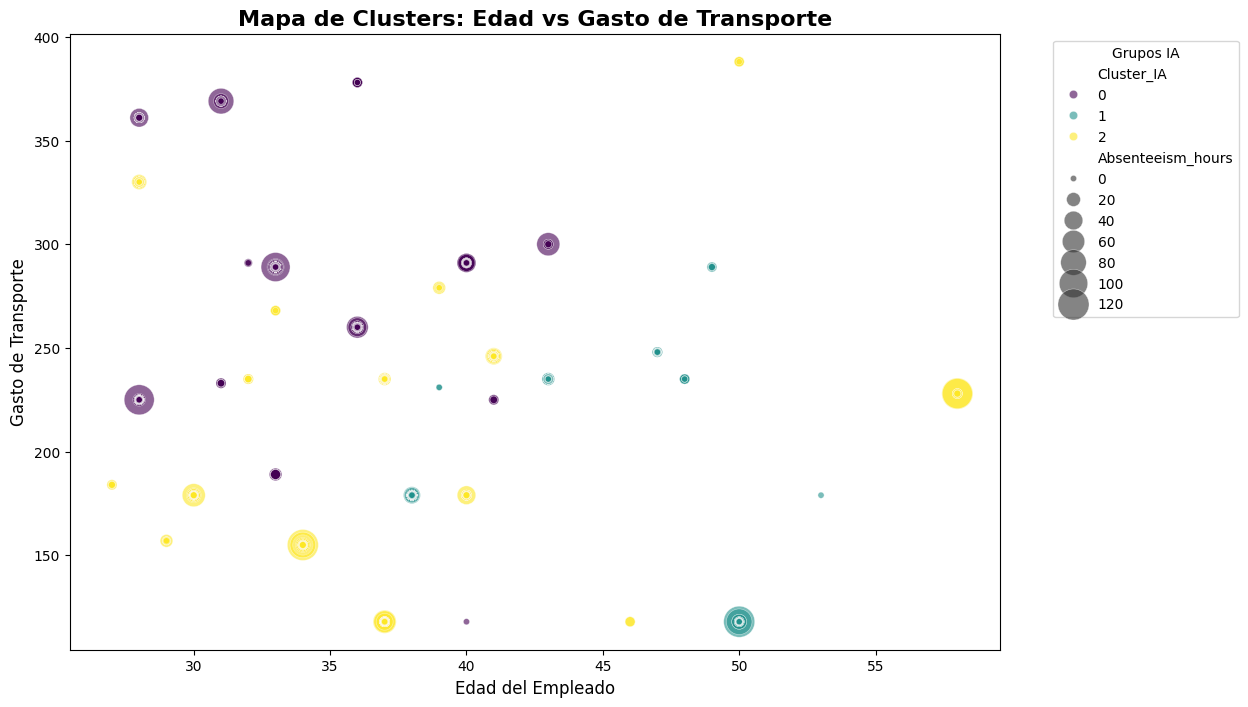

In [ ]:
plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=RRHH_full, 
    x='Age', 
    y='Transportation_expense', 
    hue='Cluster_IA', 
    size='Absenteeism_hours', 
    sizes=(20, 500), 
    palette='viridis', 
    alpha=0.6,
    edgecolor='w'
)

plt.title('Mapa de Clusters: Edad vs Gasto de Transporte', fontsize=16, weight='bold')
plt.xlabel('Edad del Empleado', fontsize=12)
plt.ylabel('Gasto de Transporte', fontsize=12)
plt.legend(title='Grupos IA', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(False)

plt.show()

<Figure size 3000x1000 with 0 Axes>

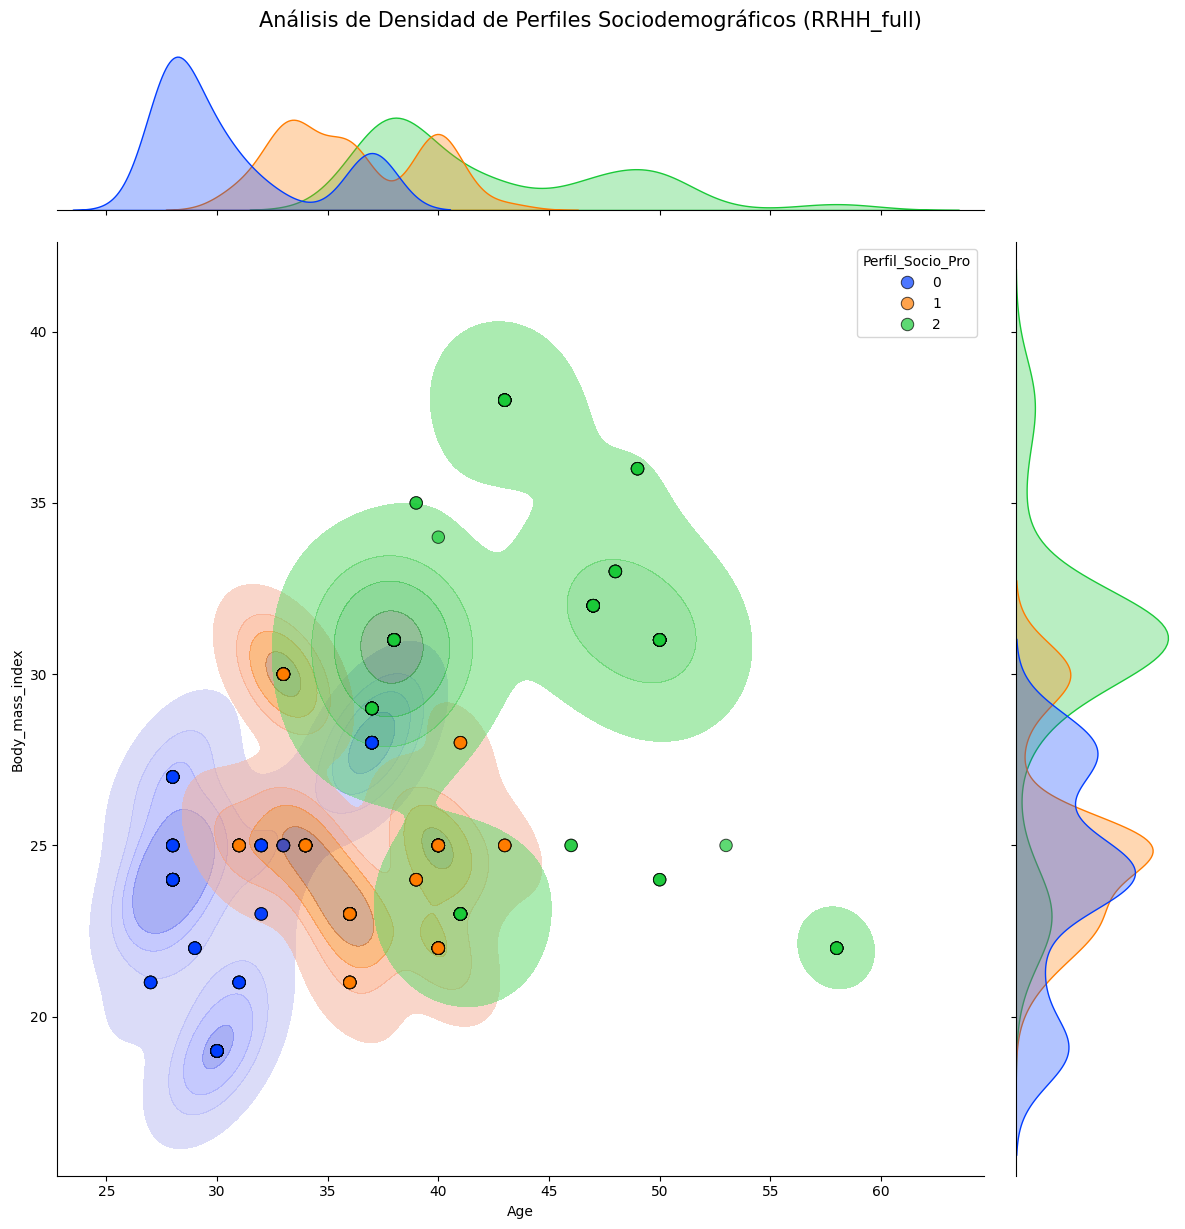

In [49]:


# 1. Usamos las variables sociodemográficas pro
features_pro = ['Body_mass_index', 'Age', 'Son', 'Service_time']

# Escalamos los datos de RRHH_full
scaler = StandardScaler()
X_scaled_pro = scaler.fit_transform(RRHH_full[features_pro])

# 2. Aplicamos la IA para crear los perfiles Pro
kmeans_pro = KMeans(n_clusters=3, random_state=100, n_init=10)
RRHH_full['Perfil_Socio_Pro'] = kmeans_pro.fit_predict(X_scaled_pro)

# 3. Gráfico de "Nivel Experto": JointPlot de Densidad
# Usamos Age e Index de Masa Corporal para los ejes
plt.figure(figsize=(30, 10))
g = sns.JointGrid(data=RRHH_full, x='Age', y='Body_mass_index', hue='Perfil_Socio_Pro', palette='bright', height=12)

# Dibujamos las capas de densidad (KDE) y los puntos (Scatter)
g.plot_joint(sns.kdeplot, fill=True, alpha=0.5, zorder=0, levels=5)
g.plot_joint(sns.scatterplot, s=80, alpha=0.7, edgecolor='k')

# Añadimos los histogramas en los bordes para ver las curvas de cada grupo
g.plot_marginals(sns.kdeplot, fill=True, alpha=0.3)

g.fig.suptitle('Análisis de Densidad de Perfiles Sociodemográficos (RRHH_full)', fontsize=15, y=1.02)
plt.show()

In [51]:
df_size = RRHH_full['Perfil_Socio_Pro'].value_counts().reset_index()
df_size.columns = ['Perfil_Socio_Pro', 'Cantidad_Empleados']
df_size = df_size.sort_values('Perfil_Socio_Pro')

df_size

,Perfil_Socio_Pro,Cantidad_Empleados
1,0,241
2,1,213
0,2,252


In [53]:
# Creamos el DataFrame de medias para los nuevos perfiles 'Pro'
perfilado_pro = RRHH_full.groupby('Perfil_Socio_Pro')[features_pro + ['Absenteeism_hours']].mean()

# Renombramos las columnas para que el reporte quede más limpio
perfilado_pro.columns = ['IMC Promedio', 'Edad Promedio', 'Hijos Promedio', 'Antigüedad Promedio', 'Horas Absentismo']
display(perfilado_pro.sort_values(by='Horas Absentismo', ascending=False))

,IMC Promedio,Edad Promedio,Hijos Promedio,Antigüedad Promedio,Horas Absentismo
Perfil_Socio_Pro,,,,,
1,25.140845,36.093897,2.295775,12.868545,9.568075
2,30.273810,42.448413,0.615079,16.559524,6.496032
0,24.153527,30.576763,0.435685,7.917012,5.676349


<p style="padding: 15px; background-color: #2c3e50; color: white; border-radius: 8px; font-family: sans-serif; text-align: center;"> Caracterización de Perfiles "Pro"</p>
En esta etapa, nuestro modelo de Machine Learning ha procesado los registros para encontrar el equilibrio entre salud, edad y compromiso familiar.

**Variables Utilizadas** (El ADN del Perfil)
Hemos seleccionado las 4 variables con mayor poder de segmentación:

Age (Edad): Define la madurez y la etapa vital.

Body_mass_index (IMC): Indicador clave de salud física.

Son (Hijos): Factor principal de necesidad de conciliación.

Service_time (Antigüedad): Mide la lealtad y experiencia en la empresa.

**Interpretación del Mapa de Densidad (JointPlot)**
El gráfico nos revela cómo se distribuye la masa crítica de la plantilla:

Ejes X-Y: Cruzamos Edad contra IMC. Las "islas" de color muestran dónde se concentra el "empleado tipo" de cada grupo.

Curvas Marginales: Las curvas en los bordes confirman que cada grupo tiene una "firma" de edad única. El grupo de Veteranos (verde) está claramente desplazado hacia la derecha.

**Análisis de Resultados (df_final)**
Esta es la radiografía matemática de nuestras 3 "Tribus de Empleados":